# 12장. 군집분석: 타깃마케팅을 위한 K-평균 군집화

## 3. 데이터 수집

In [60]:
import pandas as pd
import math

In [61]:
retail_df = pd.read_excel('./12장_data/Online_Retail.xlsx')
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. 데이터 준비 및 탐색

### 4.1 데이터 정제하기 

1) 데이터 정보 확인하기
2) 데이터 정제하기

In [62]:
retail_df = retail_df[retail_df['Quantity']> 0]
retail_df = retail_df[retail_df['UnitPrice']> 0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

retail_df.info()
retail_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.3+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [63]:
#중복 확인
print(retail_df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [64]:
retail_df[retail_df.duplicated(keep = False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


In [65]:
#중복 제거
retail_df.drop_duplicates(inplace = True)

print(retail_df.shape)

(392692, 8)


## 4.2 데이터프레임의 컬럼 추출 및 분석용 데이터 생성하기

### 1) 데이터 탐색

In [66]:
#StockCode 개수 -> 제품 수 , InvoiceNo 개수 -> 거래 건수, CustomerID 개수 -> 고객 수
r_df = pd.DataFrame({'Counts': [
            retail_df['StockCode'].nunique(),
            retail_df['InvoiceNo'].nunique(),
            retail_df['CustomerID'].nunique()
            ]}, index = ['Product','Transaction','Customer'])
r_df

,Counts
Product,3665
Transaction,18532
Customer,4338


In [67]:
retail_df['Country'].value_counts()
# print(retail_df['Country'].count())

Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


In [68]:
retail_df['CustomerID'].value_counts()

CustomerID
17841    7676
14911    5670
14096    5111
12748    4412
14606    2677
         ... 
15070       1
17102       1
17763       1
16078       1
13017       1
Name: count, Length: 4338, dtype: int64

In [69]:
retail_df['StockCode'].value_counts()

StockCode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
          ... 
90214T       1
47016        1
90181A       1
84550        1
23843        1
Name: count, Length: 3665, dtype: int64

### 2) 마케팅에 이용할 데이터 추출

In [70]:
#주문 금액 컬럼 추가
retail_df['SaleAmount'] = retail_df['UnitPrice'] * retail_df['Quantity']
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SaleAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [71]:
#각 고객 주문정보 추출을 위해 CustomerID 기준으로 그룹화, 주문 횟수 계산 위해 InvoiceNo의 개수 구하여
#주문금액의 총액을 구하고 주문일 중 가장 최신 날짜를 찾아 새로운 데이터프레임에 저장
aggregation = {
    'InvoiceNo': 'count',
    'SaleAmount': 'sum',
    'InvoiceDate': 'max'
}
customer_df = retail_df.groupby('CustomerID').agg(aggregation)
customer_df = customer_df.reset_index()
customer_df.head()

,CustomerID,InvoiceNo,SaleAmount,InvoiceDate
0,12346,1,77183.60,2011-01-18 10:01:00
1,12347,182,4310.00,2011-12-07 15:52:00
2,12348,31,1797.24,2011-09-25 13:13:00
3,12349,73,1757.55,2011-11-21 09:51:00
4,12350,17,334.40,2011-02-02 16:01:00


In [72]:
import matplotlib.pyplot as plt
import numpy as np

In [73]:
# 1. InvoiceDate를 datetime 형식으로 변환 (이미 되어있을 가능성이 높지만 안전을 위해)
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

# 2. '월'을 추출하여 새로운 열 생성
customer_df['Month'] = customer_df['InvoiceDate'].dt.strftime('%Y-%m') 

# 3. '월'별로 'Amount' 데이터를 그룹화하여 리스트의 리스트로 만듭니다.
# 월 순서를 정렬하기 위해 unique()를 사용하고 sort_values()로 정렬할 수 있습니다.
sorted_months = customer_df['Month'].unique()
sorted_months.sort()

# 각 월의 'Amount' 데이터를 담을 리스트
data_by_month = []
for month in sorted_months:
    # 해당 월의 'Amount' 데이터만 추출하여 리스트에 추가
    month_data = customer_df[customer_df['Month'] == month]['SaleAmount'].tolist()
    data_by_month.append(month_data)

# labels는 이제 '월'의 목록이 됩니다.
plot_labels = sorted_months

C:\Users\user\AppData\Local\Temp\ipykernel_17452\999774081.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_month, patch_artist=True, vert=True, labels= plot_labels)


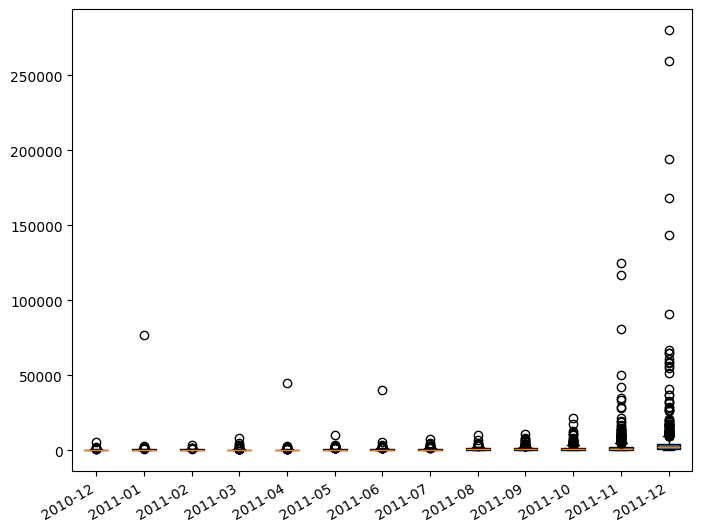

In [74]:
plt.figure(figsize=(8, 6))
plt.boxplot(data_by_month, patch_artist=True, vert=True, labels= plot_labels)
plt.xticks(rotation=30, ha='right')
plt.show()

### 3) 마지막 주문일로부터 경과일 수 계산  (기준일: 2011.12.10)

In [75]:
import datetime

#컬럼 이름 바꾸기
customer_df = customer_df.rename(columns = {'InvoiceNo': 'Freq', 'InvoiceDate': 'ElapsedDays'})
customer_df['ElapsedDays'] = datetime.datetime(2011,12,10) - customer_df['ElapsedDays']

customer_df['ElapsedDays'] = customer_df['ElapsedDays'].apply(lambda x: x.days + 1)
customer_df.head()

,CustomerID,Freq,SaleAmount,ElapsedDays,Month
0,12346,1,77183.60,326,2011-01
1,12347,182,4310.00,3,2011-12
2,12348,31,1797.24,76,2011-09
3,12349,73,1757.55,19,2011-11
4,12350,17,334.40,311,2011-02


## 4.3 데이터 분포 조정하기

### - 현재 데이터 분포를 박스플롯으로 확인

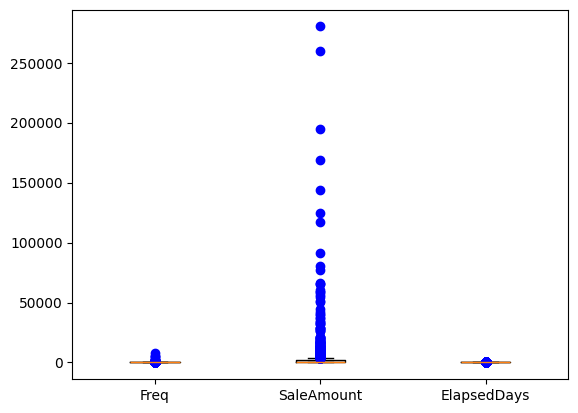

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax.boxplot([customer_df['Freq'], customer_df['SaleAmount'], customer_df['ElapsedDays']],  sym = 'bo')
plt.xticks([1,2,3], ['Freq','SaleAmount','ElapsedDays'])
plt.show()

### - 데이터 값의 왜곡(치우침)을 줄이기 위한 작업 : 로그 함수로 분포 조정

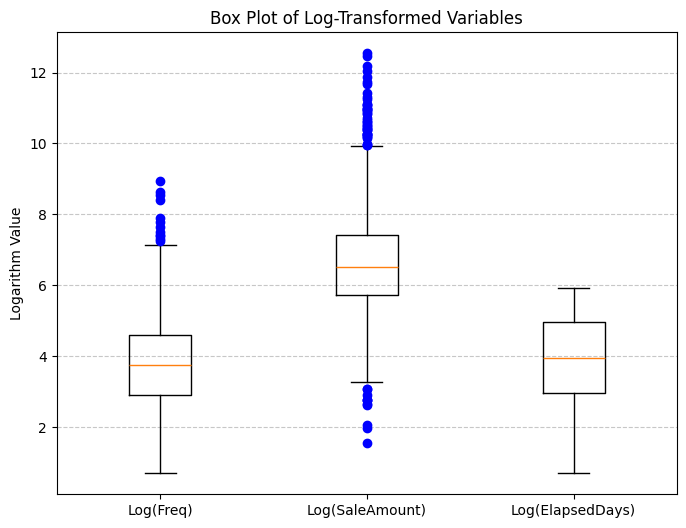

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,6))

# 1. 데이터에 로그 변환 적용 (0이나 음수가 없다고 가정), log1p는 log(1+x)를 의미함. 극단값 완화용
customer_df['log_freq'] = np.log1p(customer_df['Freq'])
customer_df['log_saleamount'] = np.log1p(customer_df['SaleAmount'])
customer_df['log_elapsed_days'] = np.log1p(customer_df['ElapsedDays'])

# 2. 로그 변환된 데이터로 박스 플롯 그리기
###  sym = 'bo'의 의미: 심볼. 이상치(outliers) 표현을 어떻게 할 것인가?>에 대한 표현, bo는 파란 원.
ax.boxplot([customer_df['log_freq'], customer_df['log_saleamount'], customer_df['log_elapsed_days']], sym = 'bo')

# 3. 플롯 설정
plt.xticks([1, 2, 3], ['Log(Freq)', 'Log(SaleAmount)', 'Log(ElapsedDays)'])
plt.title('Box Plot of Log-Transformed Variables')
plt.ylabel('Logarithm Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 이상치 표기

- sym = 'bo'
  - 'b' (색상, Color): 마커의 색상을 **파란색(blue)**으로 지정
    - 다른 예: 'r' (빨간색), 'g' (녹색), 'k' (검은색) 등.
  - 'o' (마커 형태, Marker): 이상치 마커의 형태를 **원(circle)**으로 지정
    - 다른 예: '+' (플러스), 'x' (X), 's' (사각형), 'd' (다이아몬드) 등.

## 5. 분석 모델 구축 : K-평균 군집화 모델

### 1) X_features를 정규 분포로 스케일링하기

In [79]:
! pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 60.3 MB/s  0:00:00

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- -------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# 정규 분포로 스케일링하기
from sklearn.preprocessing import StandardScaler

In [88]:
X_features = customer_df[['log_freq', 'log_saleamount', 'log_elapsed_days']].values

#스케일링
X_features_scaled = StandardScaler().fit_transform(X_features)

### 2) 엘보 방법으로 클러스터 개수 k 선택하기

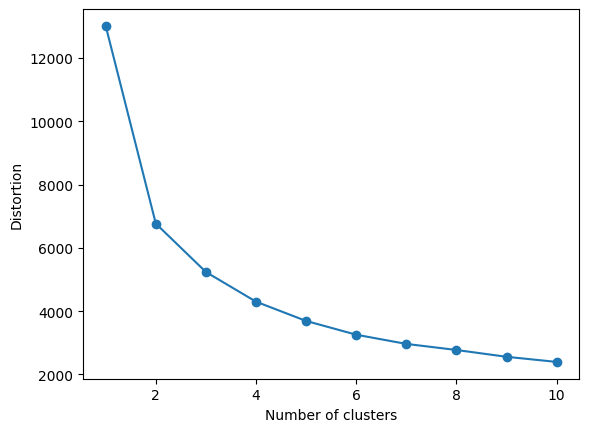

In [89]:
distortions = []

for i in range(1, 11):
    kmeans_i = KMeans(n_clusters = i, random_state = 0, n_init='auto') #모델 생성
    kmeans_i.fit(X_features_scaled) #모델 훈련
    distortions.append(kmeans_i.inertia_)
    
plt.plot(range(1,11), distortions, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto') #모델 생성

#모델 학습과 결과 예측(클러스터 라벨 생성)
Y_labels = kmeans.fit_predict(X_features_scaled)

In [91]:
customer_df['ClusterLabel'] = Y_labels

customer_df.head() #작업 확인용 출력

,CustomerID,Freq,SaleAmount,ElapsedDays,Month,log_freq,log_saleamount,log_elapsed_days,ClusterLabel
0,12346,1,77183.60,326,2011-01,0.693147,11.253955,5.789960,2
1,12347,182,4310.00,3,2011-12,5.209486,8.368925,1.386294,1
2,12348,31,1797.24,76,2011-09,3.465736,7.494564,4.343805,2
3,12349,73,1757.55,19,2011-11,4.304065,7.472245,2.995732,2
4,12350,17,334.40,311,2011-02,2.890372,5.815324,5.743003,0


## 6. 결과 분석 및 시각화

### 6.1 클러스터의 비중과 데이터 분포를 차트로 시각화하기
#### - 최적의 k 찾기 (2) 실루엣 계수에 따른 각 클러스터의 비중 시각화 함수 정의

In [ ]:
cluster0 = customer_df[customer_df['ClusterLabel'] == 0] #1478
cluster1 = customer_df[customer_df['ClusterLabel'] == 1] #1027
cluster2 = customer_df[customer_df['ClusterLabel'] == 2] #1833

# print(customer_df['ClusterLabel'].count())
# print(cluster0.count())

CustomerID          1027
Freq                1027
SaleAmount          1027
ElapsedDays         1027
Month               1027
log_freq            1027
log_saleamount      1027
log_elapsed_days    1027
ClusterLabel        1027
dtype: int64


In [117]:
cluster2.describe()

,CustomerID,Freq,SaleAmount,ElapsedDays,log_freq,log_saleamount,log_elapsed_days,ClusterLabel
count,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.0
mean,15294.004910,59.383524,1089.658905,66.363339,3.896095,6.674773,3.797891,2.0
std,1705.311852,40.064968,2395.183123,63.568045,0.662550,0.707758,0.956384,0.0
min,12346.000000,1.000000,114.340000,1.000000,0.693147,4.747884,0.693147,2.0
25%,13810.000000,31.000000,501.120000,23.000000,3.465736,6.218839,3.178054,2.0
50%,15320.000000,49.000000,777.530000,46.000000,3.912023,6.657408,3.850148,2.0
75%,16732.000000,77.000000,1240.110000,85.000000,4.356709,7.123761,4.454347,2.0
max,18287.000000,326.000000,77183.600000,373.000000,5.789960,11.253955,5.924256,2.0


In [ ]:
from matplotlib import cm

def silhouetteViz(n_cluster, X_features):
    kmeans = KMeans(n_clusters = n_cluster, random_state = 0, n_init='auto')
    Y_labels = kmeans.fit_predict(X_features)                       #학습과 클러스터 라벨 예측 한 번에 해줌
    
    #실루엣 값 계산
    #범위: -1 ~ 1/ 1에 가까울수록 good 분리, 0에 가까울수록 혼잡(섞여있음)-> 클러스터 더 필요하구나!, -1은 걍 잘못됨-> 다시 클러스터링
    silhouette_values = silhouette_samples(X_features, Y_labels, metric = 'euclidean')

    y_ax_lower, y_ax_upper = 0, 0
    y_ticks = []
    
    for c in range(n_cluster):
        c_silhouettes = silhouette_values[Y_labels == c]
        c_silhouettes.sort()
        y_ax_upper += len(c_silhouettes)
        color = cm.jet(float(c) / n_cluster)
        plt.barh( range(y_ax_lower, y_ax_upper), c_silhouettes, height= 1.0, edgecolor = 'none', color = color)
        y_ticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouettes)
      
    #평균 실루엣 표시: 빨간 점선 = 전체 평균 실루엣 점수
    #평균 실루엣 점수(빨간 점선) 일반적으로:
    #0.5 이상: 꽤 괜찮은 군집(데이터 따라 다름)
    #0.2~0.5: 애매하지만 의미는 있는 군집
    #0.2 미만: 약한 군집  
    silhouette_avg = np.mean(silhouette_values)
    plt.axvline(silhouette_avg, color = 'red', linestyle = '--')
    plt.title( 'Number of Cluster : '+ str(n_cluster) + '\n' +'Silhouette Score : '+ str(round(silhouette_avg,3)))
    plt.yticks(y_ticks, range(n_cluster))
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.ylabel('Cluster')
    plt.xlabel('Silhouette coefficient')
    plt.tight_layout()
    plt.show()

### - 클러스터 수(k) 3, 4, 5, 6인 경우의 실루엣 score 및 각 클러스터 비중 시각화

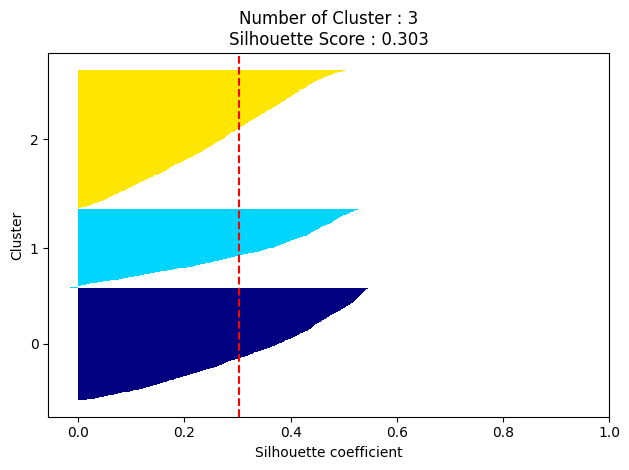

In [119]:
silhouetteViz(3, X_features_scaled)

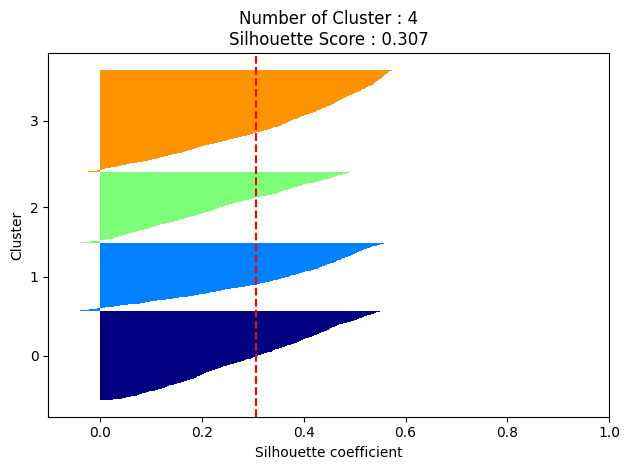

In [120]:
silhouetteViz(4, X_features_scaled)

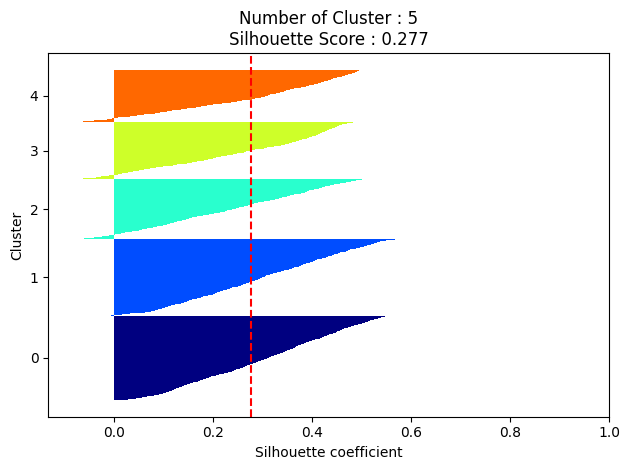

In [121]:
silhouetteViz(5, X_features_scaled)

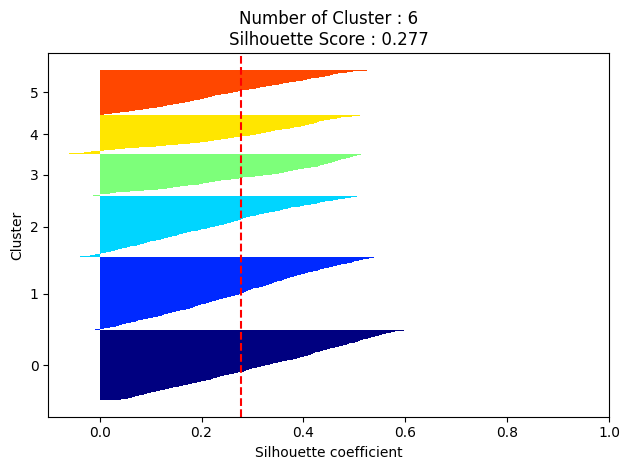

In [122]:
silhouetteViz(6, X_features_scaled)

### - 클러스터 수(k)에 따른 클러스터 데이터 분포의 시각화 함수 정의

In [123]:
def clusterScatter(n_cluster, X_features):
    c_colors = []
    kmeans = KMeans(n_clusters = n_cluster, random_state = 0, n_init='auto')
    Y_labels = kmeans.fit_predict(X_features)
    
    for i in range(n_cluster):
        c_color = cm.jet(float(i) / n_cluster) #클러스터의 색상 설정
        c_colors.append(c_color)
        #클러스터의 데이터 분포를 동그라미로 시각화
        plt.scatter( X_features[Y_labels == i,0], X_features[Y_labels== i,1], 
                    marker = 'o', color = c_color, edgecolor= 'black', s = 50, label = 'cluster '+ str(i))

    #각 클러스터의 중심점을 삼각형으로 표시
    for i in range(n_cluster):
        plt.scatter(kmeans.cluster_centers_[i,0], kmeans.cluster_centers_[i,1], marker = '^', color = c_colors[i],
                    edgecolor = 'w', s = 200)
        
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

### - 클러스터 개수(k) 3, 4, 5, 6인 경우의 클러스터 데이터 분포 시각화

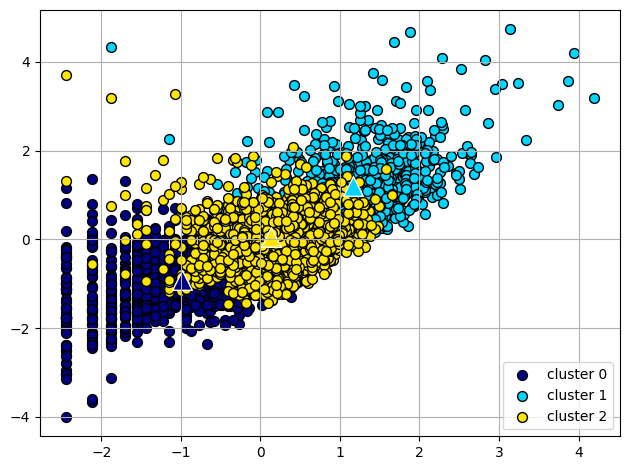

In [124]:
clusterScatter(3, X_features_scaled)

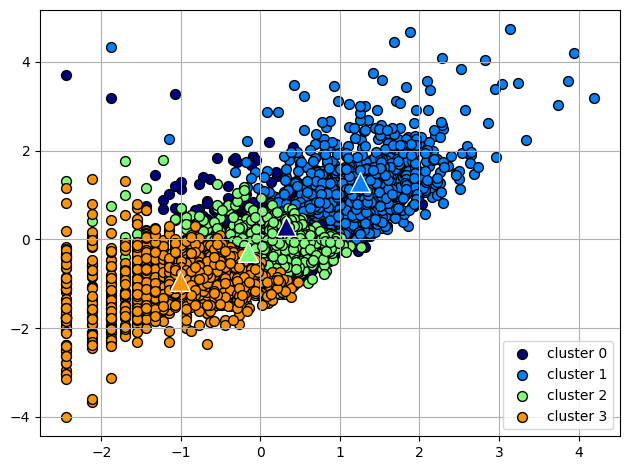

In [125]:
clusterScatter(4, X_features_scaled)

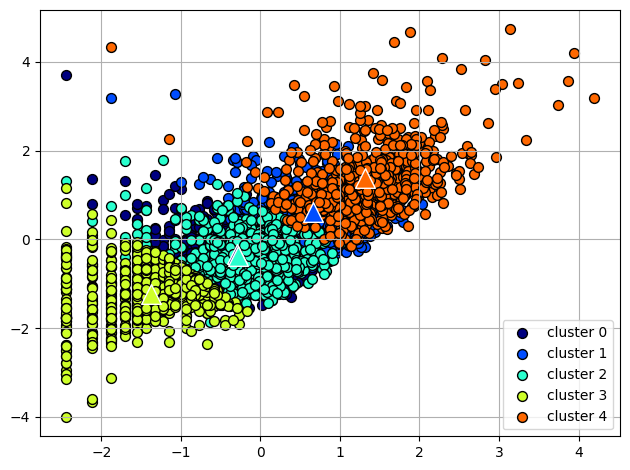

In [126]:
clusterScatter(5, X_features_scaled)

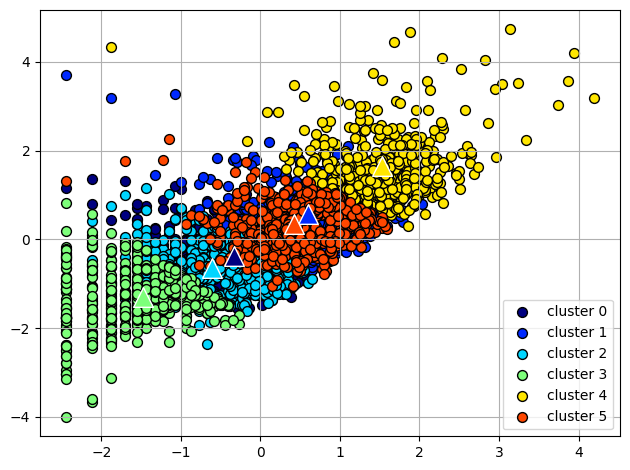

In [127]:
clusterScatter(6, X_features_scaled)